In [1]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv('/content/spam.csv', encoding='latin-1')

In [7]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4269,ham,Great. Hope you are using your connections fro...,NaN,NaN,NaN
3504,ham,"life alle mone,eppolum oru pole allalo",NaN,NaN,NaN
3560,spam,Text BANNEDUK to 89555 to see! cost 150p texto...,NaN,NaN,NaN
4219,ham,U free on sat rite? U wan 2 watch infernal aff...,NaN,NaN,NaN
300,ham,"Awesome, I remember the last time we got someb...",NaN,NaN,NaN


In [8]:
df.shape

(5572, 5)

## Data Cleaning

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [10]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'], axis=1, inplace=True)

In [11]:
df.sample(5)

,v1,v2
1834,ham,I have a rather prominent bite mark on my righ...
5389,ham,Ok.ok ok..then..whats ur todays plan
3767,ham,Where are you call me.
2234,ham,What's your room number again? Wanna make sure...
2195,ham,V-aluable. A-ffectionate. L-oveable. E-ternal....


In [12]:
df.rename(columns={
    'v1':'target',
    'v2': 'text'
}, inplace=True)

In [13]:
df.sample(5)

,target,text
3384,ham,Ok can...
4279,spam,WINNER!! As a valued network customer you have...
4913,ham,You've already got a flaky parent. It'snot sup...
1065,ham,No my mum went 2 dentist.
2801,ham,And smile for me right now as you go and the w...


In [14]:
from sklearn.preprocessing import LabelEncoder
enc = LabelEncoder()

In [15]:
df['target']=enc.fit_transform(df['target'])

In [17]:
enc.classes_

array(['ham', 'spam'], dtype=object)

In [16]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [18]:
df.isnull().sum()

,0
target,0
text,0


In [19]:
df.duplicated().sum()

np.int64(403)

In [20]:
df = df.drop_duplicates(keep='first')

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.shape

(5169, 2)

## EDA

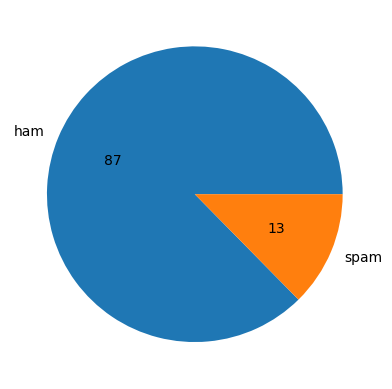

In [26]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct='%.f')
plt.show()

In [27]:
import nltk

In [32]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [33]:
df['num_chars']=df['text'].apply(len)

In [34]:
df['num_words']=df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [38]:
df['num_sent']=df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [39]:
df.head()

,target,text,num_chars,num_words,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [41]:
df[['num_chars','num_words','num_sent']].describe()

,num_chars,num_words,num_sent
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [42]:
import seaborn as sns

<Axes: xlabel='num_chars', ylabel='Count'>

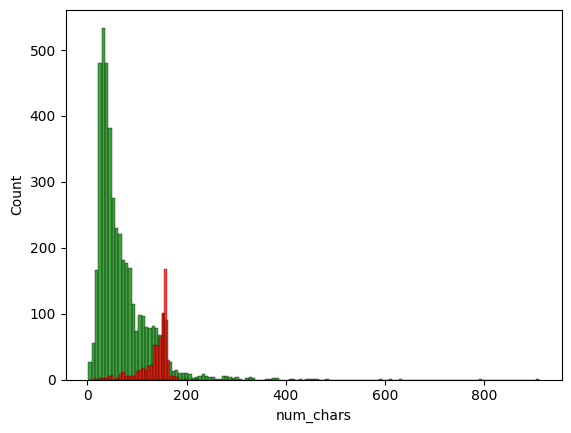

In [44]:
sns.histplot(df[df['target']==0]['num_chars'], color='green')
sns.histplot(df[df['target']==1]['num_chars'], color='red')

<Axes: xlabel='num_words', ylabel='Count'>

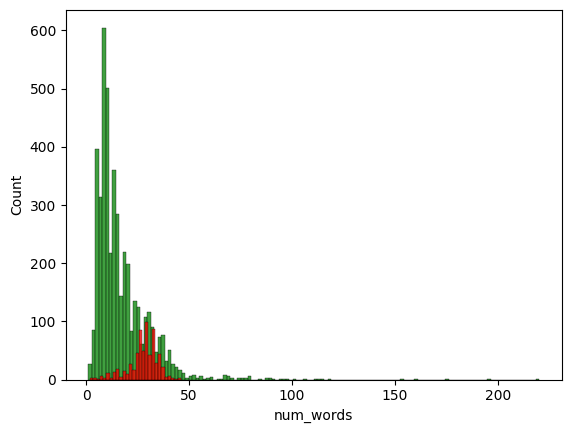

In [45]:
sns.histplot(df[df['target']==0]['num_words'], color='green')
sns.histplot(df[df['target']==1]['num_words'], color='red')

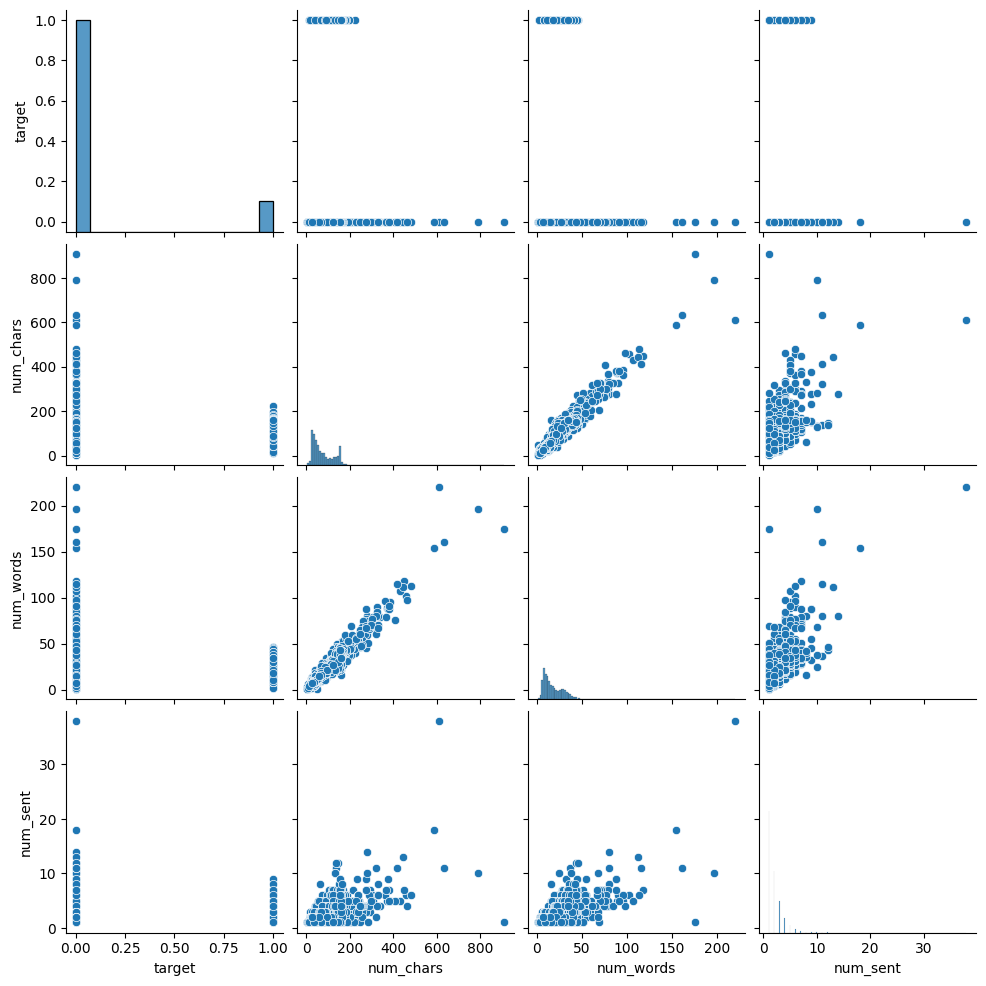

In [48]:
sns.pairplot(df)

<Axes: >

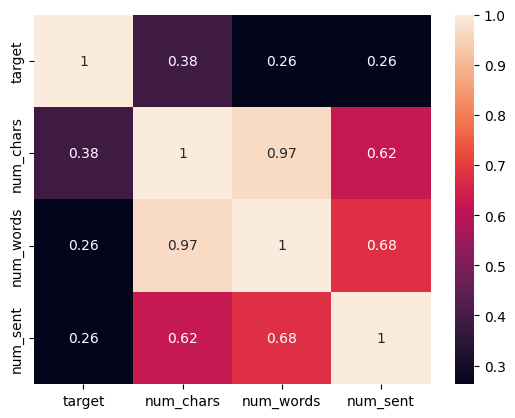

In [49]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [ ]:
df.drop(columns=['num_words', 'num_sent'], axis=1, inplace=True)

## Data/Text Preprocessing

In [54]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [64]:
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer

In [73]:
def trasform(text):
  # lowercase
  text = text.lower()

  # tokenization
  text = nltk.word_tokenize(text)

  # remove special character
  x=[]
  for i in text:
    if i.isalnum():
      x.append(i)

  text = x[:]
  x.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      x.append(i)

  text = x[:]
  x.clear()

  # stemming
  for i in text:
    x.append(PorterStemmer().stem(i))

  return " ".join(x)

In [74]:
trasform('Machine learning is the subset of AI #$')

'machin learn subset ai'

In [78]:
trasform(df['text'][8])

'winner valu network custom select receivea prize reward claim call claim code kl341 valid 12 hour'

In [79]:
df['transformed_text'] = df['text'].apply(trasform)

In [80]:
df.head()

,target,text,num_chars,num_words,num_sent,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [102]:
from wordcloud import WordCloud
wc = WordCloud(width=800, height=800, min_font_size=5, background_color='white')

In [103]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=' '))

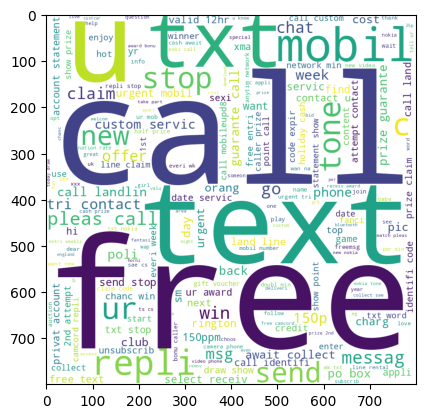

In [104]:
plt.imshow(spam_wc)

In [105]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=' '))

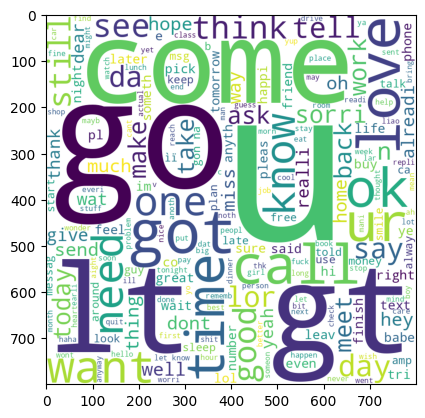

In [106]:
plt.imshow(ham_wc)

## Model Building

In [149]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

In [150]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [151]:
X.shape

(5169, 6708)

In [152]:
y = df['target'].values

In [153]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [154]:
from sklearn.model_selection import train_test_split

In [155]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [156]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [157]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [158]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.8636363636363636
[[772 117]
 [ 24 121]]
0.5084033613445378


In [159]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.9613152804642167
[[888   1]
 [ 39 106]]
0.9906542056074766


In [160]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.9661508704061895
[[885   4]
 [ 31 114]]
0.9661016949152542


In [ ]:
# tfidf : MNB

In [161]:
from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC

from sklearn.naive_bayes import MultinomialNB

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

In [163]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=80, random_state=42)
abc = AdaBoostClassifier(n_estimators=80, random_state=42)
bgc = BaggingClassifier(n_estimators=80, random_state=42)
etc = ExtraTreesClassifier(n_estimators=80, random_state=42)
gbc = GradientBoostingClassifier(n_estimators=80, random_state=42)
xgb = XGBClassifier()

In [164]:
clfs = {
    'SVC':svc,
    'KNC':knc,
    'MNB':mnb,
    'DTC':dtc,
    'LRC':lrc,
    'RFC':rfc,
    'ABC':abc,
    'BGC':bgc,
    'ETC':etc,
    'GBC':gbc,
    'XGB':xgb
}


In [165]:
def train_clfs(clf, X_train, y_train, X_test, y_test):
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  pre = precision_score(y_test, y_pred)

  return acc, pre

In [166]:
acc_scores = []
pre_scores = []

for name,clf in clfs.items():
  acc, pre = train_clfs(clf, X_train,y_train,X_test,y_test)

  acc_scores.append(acc)
  pre_scores.append(pre)

In [169]:
performance = pd.DataFrame({'Algo':clfs.keys(), 'Accuracy':acc_scores, 'Precision': pre_scores}).sort_values('Precision', ascending=False)

In [171]:
performance

,Algo,Accuracy,Precision
1,KNC,0.896518,1.000000
8,ETC,0.976789,1.000000
5,RFC,0.968085,0.991228
2,MNB,0.961315,0.990654
9,GBC,0.966151,0.966102
10,XGB,0.976789,0.961832
0,SVC,0.971954,0.939394
7,BGC,0.961315,0.877698
4,LRC,0.943907,0.865546
6,ABC,0.922631,0.828283


In [182]:
# Picing top 3 models based on precision

In [200]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=3000)

In [201]:
X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

In [202]:
from sklearn.model_selection import train_test_split

In [203]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [204]:
mnb = MultinomialNB()
rfc = RandomForestClassifier(n_estimators=50, random_state=42)
etc = ExtraTreesClassifier(n_estimators=50, random_state=42)

In [205]:
clfs2 = {
    'MNB':mnb,
    "RFC":rfc,
    'ETC':etc
}

In [206]:
acc_scores = []
pre_scores = []

for name,clf in clfs2.items():
  acc, pre = train_clfs(clf, X_train,y_train,X_test,y_test)

  acc_scores.append(acc)
  pre_scores.append(pre)

In [207]:
performance = pd.DataFrame({'Algo':clfs2.keys(), 'Accuracy_tfidf3000':acc_scores, 'Precision_tfidf3000': pre_scores}).sort_values('Precision_tfidf3000', ascending=False)

In [208]:
performance

,Algo,Accuracy_tfidf3000,Precision_tfidf3000
1,RFC,0.974855,0.991736
0,MNB,0.972921,0.991597
2,ETC,0.980658,0.984496


## Export

In [210]:
import pickle
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))